In [1]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip -q "/content/drive/MyDrive/BraTS2023/BraTS2023_Training.zip" -d /content/

replace /content/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00324-000/BraTS-GLI-00324-000-t1c.nii.gz? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [5]:
import os

train_path = "/content/BraTS2023_Training/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

print("Total Patients:", len(os.listdir(train_path)))

FileNotFoundError: [Errno 2] No such file or directory: '/content/BraTS2023_Training/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData'

In [6]:
import os

print(os.listdir('/content'))

['.config', 'ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData', 'drive', 'sample_data']


In [7]:
import os

train_path = "/content/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

print("Total Patients:", len(os.listdir(train_path)))

Total Patients: 1251


In [15]:
from sklearn.model_selection import train_test_split
import os

all_patients = sorted(os.listdir(train_path))

train_patients, test_patients = train_test_split(
    all_patients,
    test_size=0.1,
    random_state=42
)

train_patients, val_patients = train_test_split(
    train_patients,
    test_size=0.1,
    random_state=42
)

print("Train:", len(train_patients))
print("Validation:", len(val_patients))
print("Test:", len(test_patients))

Train: 1012
Validation: 113
Test: 126


In [16]:
import os
import cv2
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset

class BraTSDataset(Dataset):
    def __init__(self, patient_list, root_dir, image_size=128):
        self.samples = []
        self.root_dir = root_dir
        self.image_size = image_size

        views = ['axial', 'sagittal', 'coronal']

        for patient in patient_list:
            patient_path = os.path.join(root_dir, patient)

            t1c_path = os.path.join(patient_path, f"{patient}-t1c.nii.gz")
            flair_path = os.path.join(patient_path, f"{patient}-t2f.nii.gz")
            seg_path = os.path.join(patient_path, f"{patient}-seg.nii.gz")

            if not (os.path.exists(t1c_path) and
                    os.path.exists(flair_path) and
                    os.path.exists(seg_path)):
                continue

            seg = nib.load(seg_path).get_fdata()

            for view in views:

                if view == 'axial':
                    total_slices = seg.shape[0]

                elif view == 'sagittal':
                    total_slices = seg.shape[1]

                else:
                    total_slices = seg.shape[2]

                for idx in range(total_slices):

                    if view == 'axial':
                        mask_slice = seg[idx, :, :]

                    elif view == 'sagittal':
                        mask_slice = seg[:, idx, :]

                    else:
                        mask_slice = seg[:, :, idx]

                    if np.sum(mask_slice) > 0:
                        self.samples.append(
                            (patient, view, idx)
                        )

        print(f"Total slices collected: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def normalize(self, img):
        img = img.astype(np.float32)

        if np.max(img) > 0:
            img = (img - np.min(img)) / (np.max(img) - np.min(img))

        return img

    def resize(self, img):
        return cv2.resize(
            img,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_AREA
        )

    def __getitem__(self, idx):

        patient, view, slice_idx = self.samples[idx]

        patient_path = os.path.join(self.root_dir, patient)

        t1c = nib.load(
            os.path.join(patient_path, f"{patient}-t1c.nii.gz")
        ).get_fdata()

        flair = nib.load(
            os.path.join(patient_path, f"{patient}-t2f.nii.gz")
        ).get_fdata()

        seg = nib.load(
            os.path.join(patient_path, f"{patient}-seg.nii.gz")
        ).get_fdata()

        if view == 'axial':

            t1c_slice = t1c[slice_idx, :, :]
            flair_slice = flair[slice_idx, :, :]
            mask_slice = seg[slice_idx, :, :]

        elif view == 'sagittal':

            t1c_slice = t1c[:, slice_idx, :]
            flair_slice = flair[:, slice_idx, :]
            mask_slice = seg[:, slice_idx, :]

        else:

            t1c_slice = t1c[:, :, slice_idx]
            flair_slice = flair[:, :, slice_idx]
            mask_slice = seg[:, :, slice_idx]

        t1c_slice = self.normalize(t1c_slice)
        flair_slice = self.normalize(flair_slice)

        mask_slice = (mask_slice > 0).astype(np.float32)

        t1c_slice = self.resize(t1c_slice)
        flair_slice = self.resize(flair_slice)
        mask_slice = self.resize(mask_slice)

        image = np.stack(
            [t1c_slice, flair_slice],
            axis=0
        )

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask_slice, dtype=torch.float32).unsqueeze(0)

        return image, mask

In [17]:
train_dataset = BraTSDataset(
    patient_list=train_patients,
    root_dir=train_path,
    image_size=128
)

Total slices collected: 207807


In [18]:
val_dataset = BraTSDataset(
    patient_list=val_patients,
    root_dir=train_path,
    image_size=128
)

test_dataset = BraTSDataset(
    patient_list=test_patients,
    root_dir=train_path,
    image_size=128
)

Total slices collected: 23455
Total slices collected: 26183


In [19]:
from torch.utils.data import DataLoader

BATCH_SIZE = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 103904
Validation batches: 11728
Test batches: 13092


Image shape: torch.Size([2, 2, 128, 128])
Mask shape: torch.Size([2, 1, 128, 128])


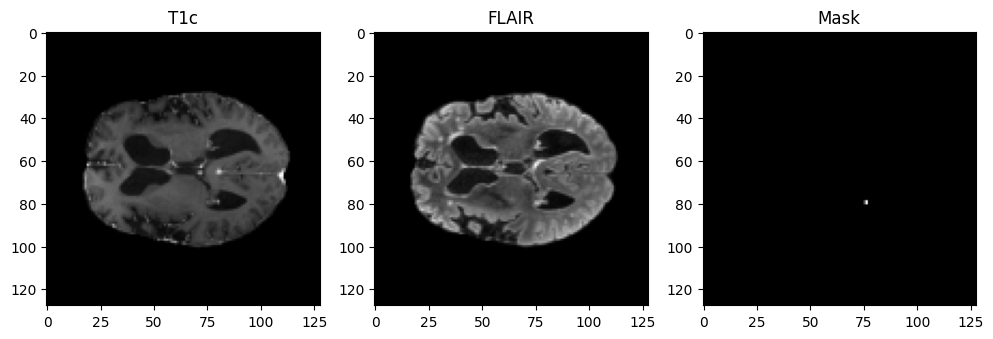

In [20]:
images, masks = next(iter(train_loader))

print("Image shape:", images.shape)
print("Mask shape:", masks.shape)

sample_image = images[0]
sample_mask = masks[0]

t1c = sample_image[0].numpy()
flair = sample_image[1].numpy()
mask = sample_mask[0].numpy()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(t1c, cmap='gray')
plt.title("T1c")

plt.subplot(1,3,2)
plt.imshow(flair, cmap='gray')
plt.title("FLAIR")

plt.subplot(1,3,3)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.show()

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -------------------------------
# Double Conv Block
# -------------------------------

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


# -------------------------------
# Simple Global Branch
# -------------------------------

class GlobalBranch(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        global_feature = F.adaptive_avg_pool2d(x, 1)

        global_feature = self.conv(global_feature)

        return x + global_feature


# -------------------------------
# Dual Branch Model
# -------------------------------

class DualBranchUNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder

        self.enc1 = DoubleConv(2, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        # Global branches

        self.global1 = GlobalBranch(32)
        self.global2 = GlobalBranch(64)
        self.global3 = GlobalBranch(128)

        # Bottleneck

        self.bottleneck = DoubleConv(128, 256)

        # Decoder

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        # Output

        self.out_conv = nn.Conv2d(32, 1, kernel_size=1)

        # Dropout

        self.dropout = nn.Dropout2d(0.3)

    def forward(self, x):

        # Encoder

        e1 = self.enc1(x)
        e1 = self.global1(e1)

        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        e2 = self.global2(e2)

        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        e3 = self.global3(e3)

        p3 = self.pool3(e3)

        # Bottleneck

        b = self.bottleneck(p3)
        b = self.dropout(b)

        # Decoder

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # Output

        out = self.out_conv(d1)

        return out

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DualBranchUNet().to(device)

print(device)

cuda


In [23]:
import torch.optim as optim

# Dice Loss

class DiceLoss(nn.Module):
    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):

        preds = torch.sigmoid(preds)

        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()

        dice = (
            (2. * intersection + self.smooth)
            /
            (preds.sum() + targets.sum() + self.smooth)
        )

        return 1 - dice


# BCE + Dice Combined

bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def combined_loss(preds, targets):

    bce = bce_loss(preds, targets)
    dice = dice_loss(preds, targets)

    return bce + dice


# Optimizer

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Loss and optimizer ready")

Loss and optimizer ready


In [24]:
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

EPOCHS = 10

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    loop = tqdm(train_loader)

    # limit batches for faster training tonight
    MAX_BATCHES = 1000

    for batch_idx, (images, masks) in enumerate(loop):

        if batch_idx >= MAX_BATCHES:
            break

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)

            loss = combined_loss(outputs, masks)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / MAX_BATCHES

    train_losses.append(epoch_loss)

    print(f"\nEpoch {epoch+1} Loss: {epoch_loss:.4f}")

/tmp/ipykernel_1232/2751790541.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
  0%|          | 0/103904 [00:00<?, ?it/s]/tmp/ipykernel_1232/2751790541.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch [1/10]:   1%|          | 1000/103904 [10:14<17:34:29,  1.63it/s, loss=1.03]



Epoch 1 Loss: 1.3326


Epoch [2/10]:   1%|          | 1000/103904 [09:58<17:05:57,  1.67it/s, loss=0.71]



Epoch 2 Loss: 0.9511


Epoch [3/10]:   1%|          | 1000/103904 [09:23<16:07:06,  1.77it/s, loss=0.776]


...


Epoch 8 Loss: 0.2793


Epoch [9/10]:   1%|          | 1000/103904 [09:33<16:23:47,  1.74it/s, loss=0.226]



Epoch 9 Loss: 0.2520


Epoch [10/10]:   1%|          | 1000/103904 [09:27<16:12:39,  1.76it/s, loss=0.415]


Epoch 10 Loss: 0.2527


In [25]:
torch.save(
    model.state_dict(),
    "/content/dual_branch_model.pth"
)

print("Model saved successfully")

Model saved successfully


In [26]:
torch.save(
    model.state_dict(),
    "/content/dual_branch_model.pth"
)

print("Model saved successfully")

Model saved successfully


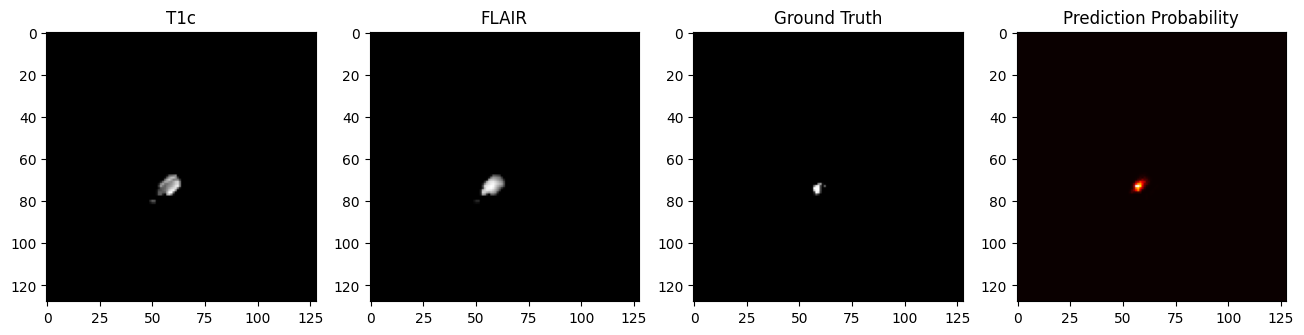

In [29]:
model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():

    outputs = model(images)

    preds = torch.sigmoid(outputs)

image = images[0].cpu()
mask = masks[0].cpu()

t1c = image[0]
flair = image[1]

gt_mask = mask[0]
pred_mask = preds[0][0].cpu().numpy()

import matplotlib.pyplot as plt

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(t1c, cmap='gray')
plt.title("T1c")

plt.subplot(1,4,2)
plt.imshow(flair, cmap='gray')
plt.title("FLAIR")

plt.subplot(1,4,3)
plt.imshow(gt_mask, cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,4,4)
plt.imshow(pred_mask, cmap='hot')
plt.title("Prediction Probability")

plt.show()

In [30]:
def dice_score(preds, targets, smooth=1):

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()

    dice = (
        (2. * intersection + smooth)
        /
        (preds.sum() + targets.sum() + smooth)
    )

    return dice


def iou_score(preds, targets, smooth=1):

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()

    union = preds.sum() + targets.sum() - intersection

    iou = (
        (intersection + smooth)
        /
        (union + smooth)
    )

    return iou


model.eval()

dice_total = 0
iou_total = 0

num_batches = 0

with torch.no_grad():

    MAX_TEST_BATCHES = 500

    for batch_idx, (images, masks) in enumerate(test_loader):

        if batch_idx >= MAX_TEST_BATCHES:
            break

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        preds = torch.sigmoid(outputs)

        preds = (preds > 0.3).float()

        dice = dice_score(preds, masks)
        iou = iou_score(preds, masks)

        dice_total += dice.item()
        iou_total += iou.item()

        num_batches += 1

avg_dice = dice_total / num_batches
avg_iou = iou_total / num_batches

print(f"\nAverage Dice Score: {avg_dice:.4f}")
print(f"Average IoU Score: {avg_iou:.4f}")


Average Dice Score: 0.6597
Average IoU Score: 0.5888


In [31]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/dual_branch_model_10epochs.pth"
)

print("Final trained model saved permanently to Google Drive")

Final trained model saved permanently to Google Drive
